# DQT

In [1]:
from datetime import datetime
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from dqt import resolve_data_dir
from dqt.panel import EQUIPMENT_MAP, GRID, WEATHERMAN_COLS, ETP_COLS, ALT_COLS, LIGHTNING_COL
from dqt.score.constants import ID_COL, COST_COL, DATE_COL, TIME_COL
from arriveds.snowflake import query_sf


/Users/rarko/Git/Projects/DQT/etp-dqt/.venv/lib/python3.12/site-packages/snowflake/connector/vendored/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.6.0)/charset_normalizer (3.5.1) doesn't match a supported version!
  warnings.warn(


In [2]:
DATA_DIR = resolve_data_dir()
sorted(DATA_DIR.glob("*"))

df_panel = pl.read_parquet(DATA_DIR / "panel_loads.parquet")
df_feats = pl.read_parquet(DATA_DIR / "features.parquet")
df_alt = df_feats.select([ID_COL] + ALT_COLS)


In [3]:
df_feats.select([ID_COL, DATE_COL] + ETP_COLS).head()

loadnumber,date,p05,p10,p15,p20,p25,p30,p35,p40,p45,p50,p55,p60,p65,p70,p75,p80,p85,p90,p95
i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
6725820,"""2025-03-26""",1196.809552,1226.188133,1246.219672,1273.851618,1291.108133,1304.612114,1314.887181,1332.244757,1344.578926,1355.36698,1367.144704,1376.907656,1388.675277,1406.696562,1420.845236,1441.461057,1461.400331,1490.469984,1543.009434
7924006,"""2025-11-20""",1321.863777,1356.767872,1395.457892,1420.790233,1442.538694,1455.26537,1482.025252,1495.340379,1508.267629,1528.955675,1539.378077,1563.144467,1578.462113,1602.353526,1629.025035,1647.830402,1673.4021,1706.96782,1749.294011
6994087,"""2025-05-22""",1382.212589,1416.223196,1431.012084,1458.106517,1478.468768,1490.529754,1508.018484,1524.849909,1532.319091,1552.083249,1568.587045,1583.033653,1606.871891,1623.644121,1650.213917,1674.426343,1718.849382,1751.732359,1841.220456
9112600,"""2026-06-24""",3665.628825,3875.487987,3962.163157,4004.839519,4079.490825,4140.676465,4186.655985,4244.746699,4308.750911,4345.000215,4387.05147,4452.771063,4540.306123,4600.675882,4662.561503,4768.42861,4913.808966,5131.883192,5399.687966
5801003,"""2024-08-16""",274.278792,306.908404,331.593636,349.084735,364.400499,372.457479,379.756386,386.220913,393.873423,402.987405,411.571521,424.702852,434.799996,444.670287,457.719419,469.711713,492.700066,525.676482,562.981941


In [4]:
df_feats.select([ID_COL, DATE_COL] + ALT_COLS).head()

loadnumber,date,alt_5,alt_10,alt_15,alt_20,alt_25,alt_30,alt_35,alt_40,alt_45,alt_50,alt_55,alt_60,alt_65,alt_70,alt_75,alt_80,alt_85,alt_90,alt_95
i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
6725820,"""2025-03-26""",0.069816,0.111284,0.157927,0.210703,0.258942,0.301876,0.349098,0.397939,0.443515,0.4888,0.534806,0.580716,0.629013,0.675183,0.724911,0.774371,0.822253,0.873338,0.926901
7924006,"""2025-11-20""",0.058861,0.10137,0.149934,0.201064,0.252748,0.29795,0.347204,0.395787,0.441583,0.491169,0.542144,0.593439,0.642073,0.692815,0.741864,0.791592,0.843315,0.894557,0.948501
6994087,"""2025-05-22""",0.055156,0.111531,0.163404,0.216267,0.26307,0.308079,0.358623,0.410545,0.460166,0.508066,0.558261,0.611547,0.665779,0.718728,0.769941,0.817946,0.865679,0.910649,0.960457
9112600,"""2026-06-24""",0.041982,0.093211,0.143358,0.18752,0.226655,0.270934,0.320355,0.370276,0.417891,0.466706,0.516815,0.567851,0.619903,0.671998,0.725929,0.779086,0.832564,0.884967,0.941889
5801003,"""2024-08-16""",0.050295,0.09363,0.135317,0.182339,0.225115,0.271716,0.321897,0.369876,0.418532,0.469991,0.52028,0.570917,0.620439,0.669797,0.719648,0.771484,0.822653,0.876621,0.933095


In [5]:
df_feats.select([ID_COL, DATE_COL] + WEATHERMAN_COLS).head()

loadnumber,date,knn_5,knn_10,knn_15,knn_20,knn_25,knn_30,knn_35,knn_40,knn_45,knn_50,knn_55,knn_60,knn_65,knn_70,knn_75,knn_80,knn_85,knn_90,knn_95
i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
6725820,"""2025-03-26""",1184.600836,1222.040125,1245.638135,1269.960303,1289.123474,1304.242249,1315.334869,1332.545093,1345.210065,1358.44281,1370.105292,1382.449707,1397.357227,1417.385583,1430.372345,1454.178638,1474.282434,1522.171301,1561.476288
7924006,"""2025-11-20""",1305.914185,1363.444934,1402.590167,1426.671631,1449.178955,1466.451697,1493.067865,1505.1854,1519.505983,1539.323059,1554.477039,1576.692065,1589.274438,1615.60979,1639.575623,1656.826416,1684.821973,1715.327441,1759.83689
6994087,"""2025-05-22""",1411.799554,1443.01665,1458.726202,1484.130273,1508.516571,1521.63999,1538.233698,1555.005444,1563.440027,1579.030029,1600.682635,1614.1146,1625.877722,1650.776416,1676.537964,1696.575366,1733.964447,1771.787048,1846.86897
9112600,"""2026-06-24""",3741.334912,3879.375757,3971.12937,4020.070508,4116.695923,4173.290381,4216.532397,4296.318457,4340.587097,4372.55481,4430.096338,4492.383252,4578.261292,4642.092944,4690.642395,4825.343701,4985.662671,5194.513794,5534.663745
5801003,"""2024-08-16""",274.229947,310.097461,336.381351,353.871429,367.382538,375.789542,384.647226,390.402277,397.665045,408.402771,421.986446,430.312604,440.2355,454.753394,462.214569,480.835809,512.850856,537.070798,582.73241


In [6]:
# df["etp50_attainment"]


In [7]:
df_feats.select(
    pl.col("loadnumber").n_unique().alias("shipments"),
    pl.col("etp50_attainment").mean().alias("etp_p50_att"),
    # pl.col("loadmiles").mean()
)

shipments,etp_p50_att
u32,f64
2386093,0.479772


In [8]:
agg_map = (
    pl.col("loadnumber").n_unique().alias("shipments"),
    pl.col("etp50_attainment").mean().alias("etp_p50_att"),
    pl.col("etp50_attainment").std().alias("etp_p50_att_std"),
)



In [9]:
# df.group_by("book_date").agg(agg_map)



In [10]:
from dqt.model import GlobalDQT

dqt = GlobalDQT()
dial = dqt.history(start="2026-01-01")
sc = dqt.spot_check(6725820)          # or features=df_feats
score = dqt.evaluate(df_panel)

proposal = dqt.propose(method="sarima", as_of="2026-08-26")
dqt.compare(proposal, dqt.latest())
# dqt.publish(proposal)  # staging only if gates.passed

2026-08-26 13:49:33.324 | WARNING  | dqt.model.global_dqt:_resolve_r_hat:1072 - no SARIMA row for 2026-08-26; using latest on/before (2026-08-20)


level,col,a,b,delta,delta_pp
f64,str,f64,f64,f64,f64
0.05,"""alt_5""",0.05,0.049411,0.000589,0.058869
0.1,"""alt_10""",0.05,0.098791,-0.048791,-4.879085
0.15,"""alt_15""",0.097586,0.136412,-0.038825,-3.882536
0.2,"""alt_20""",0.147586,0.16958,-0.021993,-2.199346
0.25,"""alt_25""",0.197586,0.209278,-0.011691,-1.169124
…,…,…,…,…,…
0.75,"""alt_75""",0.697586,0.687954,0.009632,0.963249
0.8,"""alt_80""",0.747586,0.744532,0.003054,0.305406
0.85,"""alt_85""",0.797586,0.798471,-0.000884,-0.088445


## Load Level (lookup by `load_id` for `ID_COL`)

Prefer `GlobalDQT.spot_check(loadnumber)` for dial vs dial-applied $ vs booked `p*` QA.


In [11]:
from dqt.model.global_dqt import GlobalDQT

dqt = GlobalDQT()
sc = dqt.spot_check(6725820, features=df_feats)
sc.summary(), sc.to_frame(long=True).head()


({'loadnumber': 6725820,
  'booked_on_date': datetime.date(2025, 3, 26),
  'alt_50': 0.48879994928010423,
  'dial_applied_50': 1355.4786616743509,
  'p50': 1355.3669795531669,
  'cost': 1200.0,
  'wm_r': 0.07056551353575145,
  'etp_r': 0.055429887245381636,
  'delta_50': 0.11168212118400334},
 shape: (5, 8)
 ┌────────────┬─────────────┬───────┬──────────┬─────────────┬─────────────┬─────────────┬──────────┐
 │ loadnumber ┆ booked_on_d ┆ level ┆ alt      ┆ weatherman  ┆ dial_applie ┆ etp_booked  ┆ delta    │
 │ ---        ┆ ate         ┆ ---   ┆ ---      ┆ ---         ┆ d           ┆ ---         ┆ ---      │
 │ i64        ┆ ---         ┆ f64   ┆ f64      ┆ f64         ┆ ---         ┆ f64         ┆ f64      │
 │            ┆ date        ┆       ┆          ┆             ┆ f64         ┆             ┆          │
 ╞════════════╪═════════════╪═══════╪══════════╪═════════════╪═════════════╪═════════════╪══════════╡
 │ 6725820    ┆ 2025-03-26  ┆ 0.05  ┆ 0.069816 ┆ 1184.600836 ┆ 1199.438544 ┆ 11

In [12]:
load_id = 6725820

df_ld = df_feats.filter(pl.col("loadnumber") == load_id)
panel_ld = df_panel.filter(pl.col("loadnumber") == load_id)

book_date = df_ld.select(DATE_COL).item()
book_time = df_ld.select(TIME_COL).item()

book_date = datetime.fromisoformat(book_date)
book_date_str = book_date.strftime("%Y-%m-%d")
book_ts = pd.Timestamp(book_time)

In [13]:
# df_ld.select([ID_COL, DATE_COL] + ETP_COLS).head()
# df_ld.select([ID_COL, DATE_COL] + ALT_COLS).head()
# df_ld.select([ID_COL, DATE_COL] + WEATHERMAN_COLS).head()


In [14]:
ETP_COL = "p50"
qs = GRID.copy()

w_qs = df_ld.select(WEATHERMAN_COLS).to_pandas().values[0]
etp_qs = df_ld.select(ETP_COLS).to_pandas().values[0]
alt_qs = df_ld.select(ALT_COLS).to_pandas().values[0]

light_pred = df_ld.select(LIGHTNING_COL).item()
etp_pred = df_ld.select(ETP_COL).item()
true_cost = panel_ld.select(COST_COL).item()

In [15]:
df_ld.select(WEATHERMAN_COLS)

knn_5,knn_10,knn_15,knn_20,knn_25,knn_30,knn_35,knn_40,knn_45,knn_50,knn_55,knn_60,knn_65,knn_70,knn_75,knn_80,knn_85,knn_90,knn_95
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1184.600836,1222.040125,1245.638135,1269.960303,1289.123474,1304.242249,1315.334869,1332.545093,1345.210065,1358.44281,1370.105292,1382.449707,1397.357227,1417.385583,1430.372345,1454.178638,1474.282434,1522.171301,1561.476288


In [16]:
alt_qs

array([0.06981569, 0.11128355, 0.15792655, 0.21070306, 0.25894246,
       0.30187624, 0.34909825, 0.39793929, 0.44351539, 0.48879995,
       0.5348058 , 0.58071648, 0.62901307, 0.67518334, 0.72491087,
       0.77437065, 0.8222534 , 0.87333804, 0.92690079])

In [17]:


abs_q_offset = np.abs(GRID - alt_qs) * 100

In [18]:
# df_feats.select([ID_COL, DATE_COL] + ETP_COLS).head()

df_feats['lightning_prediction']

lightning_prediction
f64
1383.168579
1641.461182
1581.513428
4218.805176
486.958588
…
1465.754395
2529.469238
3354.255371


In [19]:
print(f"True Cost: ${true_cost:.1f}")
print(f"Lightning Cost: ${light_pred:.1f}")
print(f"ETP `{ETP_COL}` Cost: ${etp_pred:.1f}")
# print(f"Altitude: {alt_pred:.1f}")
# print(f"Weatherman: {w_pred:.1f}")

True Cost: $1200.0
Lightning Cost: $1383.2
ETP `p50` Cost: $1355.4


In [20]:
w_qi = np.argmin(np.abs(true_cost - w_qs))     # index of best weatherman quantile
etp_qi = np.argmin(np.abs(true_cost - etp_qs)) # index of best etp quantile
bst_w = w_qs[w_qi]
bst_etp = etp_qs[etp_qi]
best_w_quantile = int(GRID[w_qi] * 100)
best_etp_quantile = int(GRID[etp_qi] * 100)


print(f"Best Weatherman: ${bst_w:.1f} at q{best_w_quantile}")
print(f"Best ETP: ${bst_etp:.1f} at q{best_etp_quantile}")


Best Weatherman: $1184.6 at q5
Best ETP: $1196.8 at q5


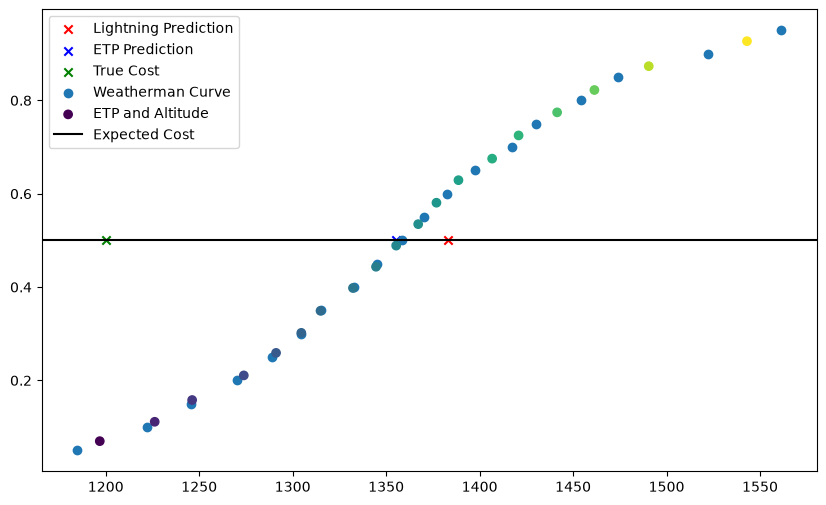

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(light_pred, .50, marker='x', color='red', label='Lightning Prediction')
ax.scatter(etp_pred, .50, marker='x', color='blue', label='ETP Prediction')
ax.scatter(true_cost, .50, marker='x', color='green', label='True Cost')

ax.scatter(w_qs, GRID, label='Weatherman Curve')
ax.scatter(etp_qs, alt_qs, c=w_qs, cmap='viridis', label='ETP and Altitude')

ax.axhline(.50, color='black', label='Expected Cost')

plt.legend()
plt.show()

In [22]:
# sql_query = f"""
#     SELECT
#         eml.*
#         , row_number() OVER (PARTITION BY eml.LoadNumber ORDER BY eml.event_timestamp_cst DESC) AS rown
#     FROM events_raw.etp.etp_model_logs AS eml
#     WHERE eml.LoadNumber = {load_id}
# """
# ld_preds = query_sf(sql_query)

# ld_preds.head()

In [23]:
sql_query = f"""
    SELECT
        eml.*
        , row_number() OVER (PARTITION BY eml.LoadNumber ORDER BY eml.event_timestamp_cst DESC) AS rown
    
        , json_extract_path_text(etp.percentiles, '"5"')::float AS P05
        , json_extract_path_text(etp.percentiles, '"10"')::float AS P10
        , json_extract_path_text(etp.percentiles, '"15"')::float AS P15
        , json_extract_path_text(etp.percentiles, '"20"')::float AS P20
        , json_extract_path_text(etp.percentiles, '"25"')::float AS P25
        , json_extract_path_text(etp.percentiles, '"30"')::float AS P30
        , json_extract_path_text(etp.percentiles, '"35"')::float AS P35
        , json_extract_path_text(etp.percentiles, '"40"')::float AS P40
        , json_extract_path_text(etp.percentiles, '"45"')::float AS P45
        , json_extract_path_text(etp.percentiles, '"50"')::float AS P50
        , json_extract_path_text(etp.percentiles, '"55"')::float AS P55
        , json_extract_path_text(etp.percentiles, '"60"')::float AS P60
        , json_extract_path_text(etp.percentiles, '"65"')::float AS P65
        , json_extract_path_text(etp.percentiles, '"70"')::float AS P70
        , json_extract_path_text(etp.percentiles, '"75"')::float AS P75
        , json_extract_path_text(etp.percentiles, '"80"')::float AS P80
        , json_extract_path_text(etp.percentiles, '"85"')::float AS P85
        , json_extract_path_text(etp.percentiles, '"90"')::float AS P90
        , json_extract_path_text(etp.percentiles, '"95"')::float AS P95

    FROM events_raw.etp.etp_model_logs AS eml
    
        INNER JOIN dapl_raw.accelerateprod.lod__loadelitetruckpurchasing AS etp
        ON etp.loadnumber = eml.loadnumber

    WHERE eml.LoadNumber = {load_id}
"""
ld_preds = query_sf(sql_query)
ld_time_preds = ld_preds.select([ID_COL, "event_timestamp_cst"] + ETP_COLS)


2026-08-26 13:50:32.261 | INFO     | arriveds.snowflake.utils:query_sf:422 - <inline sql>: 29 rows x 41 cols in 58.04s (query_id=01c6a749-0b15-3e4b-0000-94e586de9542)


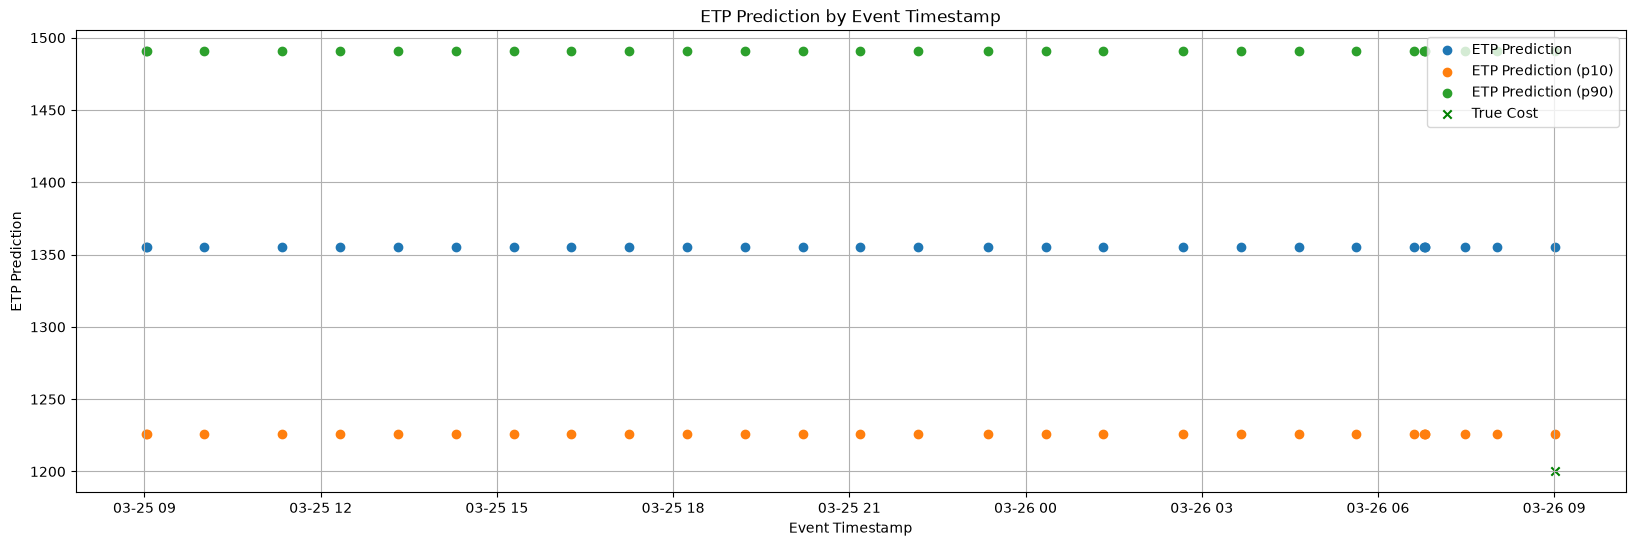

In [24]:
fig, ax = plt.subplots(figsize=(20, 6))

# ax.scatter(light_pred, .50, marker='x', color='red', label='Lightning Prediction')
# ax.scatter(etp_pred, .50, marker='x', color='blue', label='ETP Prediction')
# ax.scatter(true_cost, .50, marker='x', color='green', label='True Cost')


ax.scatter(ld_time_preds["event_timestamp_cst"], ld_time_preds["p50"], label="ETP Prediction")

ax.scatter(ld_time_preds["event_timestamp_cst"], ld_time_preds["p10"], label="ETP Prediction (p10)")
ax.scatter(ld_time_preds["event_timestamp_cst"], ld_time_preds["p90"], label="ETP Prediction (p90)")


ax.scatter(book_ts, true_cost, label="True Cost", marker="x", color="green")


ax.legend()
ax.set_xlabel("Event Timestamp")
ax.set_ylabel("ETP Prediction")
ax.set_title("ETP Prediction by Event Timestamp")

ax.grid()
plt.show()



In [25]:
from pathlib import Path

path_etp_misses = Path("SQL/etp/big_miss_shipments.sql")

COMPRESSION = "zstd"
etp_cache = DATA_DIR / "etp"
etp_parquet_files = list(etp_cache.glob("*.parquet"))

etp_misses = etp_cache / "etp_big_misses.parquet"

# df_etp_misses = query_sf(path_etp_misses)
# df_etp_misses.write_parquet(etp_misses, compression=COMPRESSION)

df_etp_misses = pl.read_parquet(etp_misses)
df_etp_misses.head()

LOADNUMBER,LOAD_EQUIPMENT_TYPE,ORIGIN_CITY_STATE,DEST_CITY_STATE,CUSTOMER_ID,ORDERSTATUS,LOADED_MILES,CLHP_MA,UHP_MA,MEAN_PRED_MKT_RT,CLHP_PRED_LINE,UHP_PRED_LINE,CLHP_PRED_TOT_COST,UHP_PRED_TOT_COST,PATH_TAKEN,MULTIPLIER,CHARGE_OVERRIDE_FLAG,TOTAL_CHARGES_USED,ACTUAL_CHARGE,ETP50,ACTUAL_COST,MARKETDISRUPTIONEVENTLISTID,ISAFFECTEDBYMARKETDISRUPTIONEVENT,ISTARGETELIGIBLE,ISETPOVERRIDE,ETP_BIG_MISSES_FLAG,BOOK_DATE,MILE_BIN,ABS_DELTA_CHARGE,ABS_PCT_DELTA_CHARGE,ABS_DELTA_ETP50_VS_COST,ABS_PCT_DELTA_ETP50_VS_COST,ABS_DELTA_ETP50_VS_HP,ABS_PCT_DELTA_ETP50_VS_HP,ABS_DELTA_ETP50_VS_UHP,ABS_PCT_DELTA_ETP50_VS_UHP,COST1,PERCENTILE1,COST2,PERCENTILE2,COST3,PERCENTILE3,COST4,PERCENTILE4,BEAT_TARGET1,BEAT_TARGET2,BEAT_TARGET3,BEAT_TARGET4
i32,str,str,str,i32,str,i16,str,str,f64,f64,f64,f64,f64,str,str,str,f64,f64,"decimal[19,2]",f64,i32,bool,bool,bool,i8,date,str,f64,f64,"decimal[38,2]","decimal[38,4]",f64,f64,f64,f64,"decimal[38,0]","decimal[38,0]","decimal[38,0]","decimal[38,0]","decimal[38,0]","decimal[38,0]","decimal[38,0]","decimal[38,0]",i8,i8,i8,i8
8843761,"""R""","""Colton, CA""","""Johnstown, NY""",57853,"""Finished""",2741,"""MA7""",null,8771.2,3431.980312,null,5679.600312,null,"""legacy_total_charges""",null,"""""",8773.941,21743.48,7318.07,19001.0,null,false,true,false,1,2026-05-12,"""e1000+""",12969.539,0.5965,11682.93,0.6149,1638.47,0.2885,null,null,6687,20,7138,40,7608,65,8020,80,0,0,0,0
8843758,"""R""","""Colton, CA""","""Brundidge, AL""",57853,"""Finished""",2092,"""MA7""",null,6819.92,2693.463039,null,4408.903039,null,"""legacy_total_charges""",null,"""""",6696.492,20683.28,6719.91,18001.0,null,false,true,false,1,2026-05-12,"""e1000+""",13986.788,0.6762,11281.09,0.6267,2311.01,0.5242,null,null,6348,20,6586,40,6898,65,7166,80,0,0,0,0
8843757,"""R""","""Colton, CA""","""Opelika, AL""",57853,"""Finished""",2102,"""MA7""",null,6852.52,2701.13347,null,4424.77347,null,"""legacy_total_charges""",null,"""""",6728.502,18360.62,6793.26,16000.0,null,false,true,true,1,2026-05-12,"""e1000+""",11632.118,0.6335,9206.74,0.5754,2368.49,0.5353,null,null,6423,20,6666,40,6978,65,7247,80,0,0,0,0
8843763,"""R""","""Colton, CA""","""London, KY""",57853,"""Finished""",2161,"""MA7""",null,6699.1,2967.616816,null,4739.636816,null,"""legacy_total_charges""",null,"""""",6917.361,17161.13,6632.31,15000.0,null,false,true,false,1,2026-05-12,"""e1000+""",10243.769,0.5969,8367.69,0.5578,1892.67,0.3993,null,null,6284,20,6524,40,6808,65,7131,80,0,0,0,0
8955378,"""VR""","""Elizabeth, NJ""","""Lakeland, FL""",54327,"""Finished""",3378,"""MA7""",null,2916.34,2372.791994,null,3273.591994,null,"""legacy_customer_specific_hyper…",null,"""""",3516.45,12293.35,2927.79,11000.0,null,false,true,true,1,2026-06-02,"""e1000+""",8776.9,0.714,8072.21,0.7338,345.8,0.1056,null,null,2671,15,2787,30,2927,50,3068,70,0,0,0,0
